In [13]:
!pip install -q kagglehub

##imports

In [14]:
import os
import numpy as np
import matplotlib.pyplot as plt
import kagglehub

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


Downloading cifake dataset from Kagglehub

In [16]:
path = kagglehub.dataset_download("birdy654/cifake-real-and-ai-generated-synthetic-images")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'cifake-real-and-ai-generated-synthetic-images' dataset.
Path to dataset files: /kaggle/input/cifake-real-and-ai-generated-synthetic-images


Setting the datast path

In [17]:
train_dir = os.path.join(path, "train")
test_dir = os.path.join(path, "test")

print("Train directory:", train_dir)
print("Test directory:", test_dir)
print("Train exists:", os.path.exists(train_dir))
print("Test exists:", os.path.exists(test_dir))

Train directory: /kaggle/input/cifake-real-and-ai-generated-synthetic-images/train
Test directory: /kaggle/input/cifake-real-and-ai-generated-synthetic-images/test
Train exists: True
Test exists: True


Transforming the Images for the Efficient model

In [18]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

Loading the dataset

In [19]:
full_train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transform)
test_dataset = datasets.ImageFolder(root=test_dir, transform=test_transform)

print("Classes:", full_train_dataset.classes)
print("Number of training images:", len(full_train_dataset))
print("Number of test images:", len(test_dataset))

Classes: ['FAKE', 'REAL']
Number of training images: 100000
Number of test images: 20000


split the dataset into test and training

In [20]:
train_size = int(0.7 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

print("Train split size:", len(train_dataset))
print("Validation split size:", len(val_dataset))

Train split size: 70000
Validation split size: 30000


Data Loader

In [21]:
batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
validation_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("DataLoaders ready.")

DataLoaders ready.


Building the Model

In [22]:
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

for param in model.features.parameters():
    param.requires_grad = False

# Replace final classifier for binary classification real vs fake
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, 2)

model = model.to(device)
print(model)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

adam optimizer, cross entropy loss

In [23]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

Same training loop as my ResNet model

In [24]:
num_epochs = 10

train_losses = []
validation_loss = []
validation_accuracy = []

for epoch in range(num_epochs):
    model.train()
    running_train_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    epoch_train_loss = running_train_loss / len(train_loader)
    train_losses.append(epoch_train_loss)

    model.eval()
    running_val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in validation_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_val_loss = running_val_loss / len(validation_loader)
    epoch_val_accuracy = correct / total

    validation_loss.append(epoch_val_loss)
    validation_accuracy.append(epoch_val_accuracy)

    scheduler.step()

    print(f"Epoch [{epoch+1}/{num_epochs}] | "
          f"Train Loss: {epoch_train_loss:.4f} | "
          f"Validation Loss: {epoch_val_loss:.4f} | "
          f"Validation Accuracy: {epoch_val_accuracy:.4f}")

Epoch [1/10] | Train Loss: 0.4501 | Validation Loss: 0.3623 | Validation Accuracy: 0.8519
Epoch [2/10] | Train Loss: 0.3649 | Validation Loss: 0.3319 | Validation Accuracy: 0.8615
Epoch [3/10] | Train Loss: 0.3463 | Validation Loss: 0.3153 | Validation Accuracy: 0.8694
Epoch [4/10] | Train Loss: 0.3432 | Validation Loss: 0.3138 | Validation Accuracy: 0.8692
Epoch [5/10] | Train Loss: 0.3389 | Validation Loss: 0.3143 | Validation Accuracy: 0.8694
Epoch [6/10] | Train Loss: 0.3397 | Validation Loss: 0.3123 | Validation Accuracy: 0.8702
Epoch [7/10] | Train Loss: 0.3403 | Validation Loss: 0.3127 | Validation Accuracy: 0.8689
Epoch [8/10] | Train Loss: 0.3353 | Validation Loss: 0.3118 | Validation Accuracy: 0.8722
Epoch [9/10] | Train Loss: 0.3386 | Validation Loss: 0.3105 | Validation Accuracy: 0.8725
Epoch [10/10] | Train Loss: 0.3363 | Validation Loss: 0.3102 | Validation Accuracy: 0.8708


##Graphs for trainign and validation loss

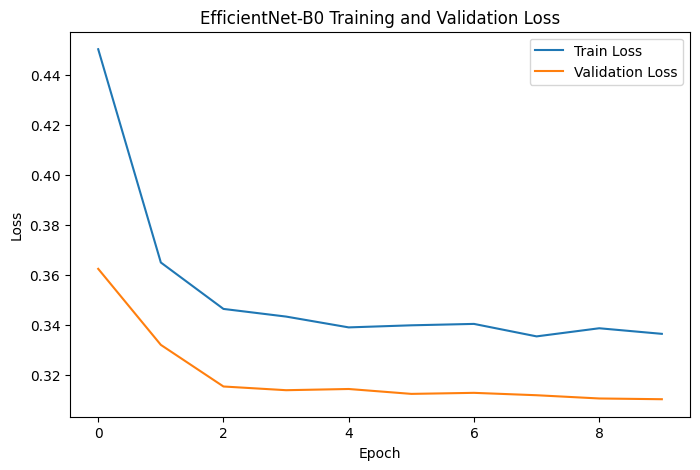

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(validation_loss, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("EfficientNet-B0 Training and Validation Loss")
plt.legend()
plt.show()

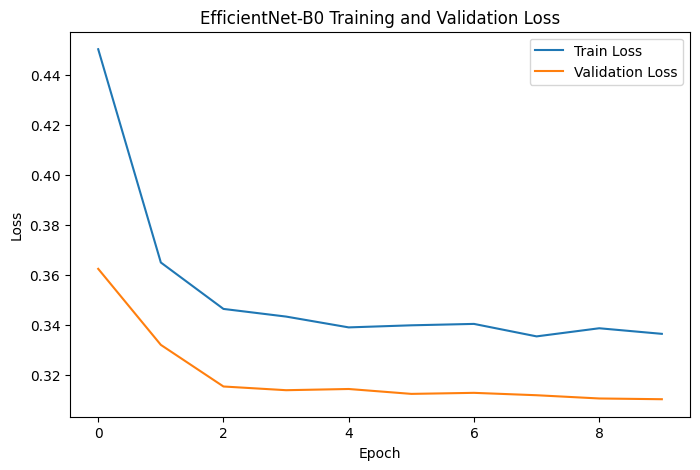

In [26]:
#Plot training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(validation_loss, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("EfficientNet-B0 Training and Validation Loss")
plt.legend()
plt.show()

Test Evaluation

In [27]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = correct / total
print(f"EfficientNet-B0 Test Accuracy: {test_accuracy:.4f}")

EfficientNet-B0 Test Accuracy: 0.8579
